# Lab 1a: The Machine Learning Context

**Signal, Image and Video Processing**

In this lab, we'll explore the concepts from Lecture 1a:
1. Understanding features, labels, and dimensions
2. Numerical vs categorical data
3. Sampling and quantization effects
4. Why ML models need fixed-size numeric vectors

We'll use real datasets to see these concepts in action.

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine, load_digits, fetch_california_housing
import warnings
warnings.filterwarnings('ignore')

# For audio examples
try:
    import librosa
    import librosa.display
    LIBROSA_AVAILABLE = True
except ImportError:
    print("librosa not installed. Audio examples will be skipped.")
    print("Install with: pip install librosa")
    LIBROSA_AVAILABLE = False

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

---
## Part 1: Understanding Features, Labels, Dimensions and Task Type

Let's start with classic ML datasets to understand these concepts.

### 1.1 The Iris Dataset — A Classification Problem

The Iris dataset contains measurements of 150 iris flowers from 3 species.

In [2]:
# Load the Iris dataset
iris = load_iris()

# What's inside?
print("Keys in the dataset:", iris.keys())
print()

Keys in the dataset: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])



In [3]:
# Features (X) - the inputs
X = iris.data
print("Features shape:", X.shape)
print(f"  → {X.shape[0]} samples (flowers)")
print(f"  → {X.shape[1]} features (measurements per flower)")
print(f"  → This is a {X.shape[1]}-dimensional dataset")
print()
print("Feature names:", iris.feature_names)

Features shape: (150, 4)
  → 150 samples (flowers)
  → 4 features (measurements per flower)
  → This is a 4-dimensional dataset

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [4]:
# Labels (Y) - the outputs we want to predict
y = iris.target
print("Labels shape:", y.shape)
print("Unique labels:", np.unique(y))
print("Label names:", iris.target_names)
print()
print("This is a CLASSIFICATION problem: predict which species (category)")

Labels shape: (150,)
Unique labels: [0 1 2]
Label names: ['setosa' 'versicolor' 'virginica']

This is a CLASSIFICATION problem: predict which species (category)


In [5]:
# Let's look at a few samples
df_iris = pd.DataFrame(X, columns=iris.feature_names)
df_iris['species'] = [iris.target_names[i] for i in y]

print("First 5 samples:")
df_iris.head()

First 5 samples:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


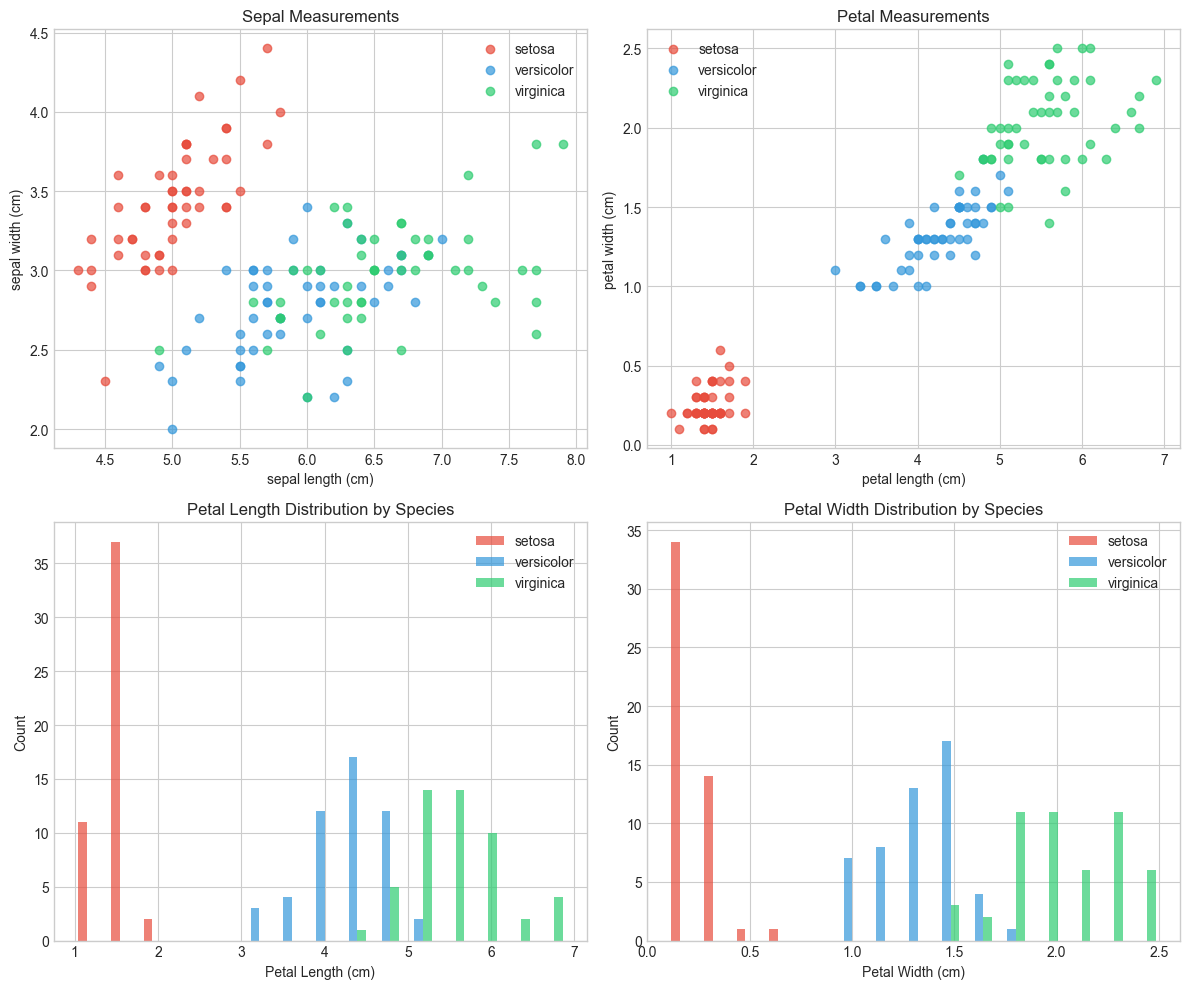


Notice: Petal measurements separate the species better than sepal measurements!
This is what 'informative features' means — some features are more useful than others.


In [6]:
# Visualize the features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

colors = ['#e74c3c', '#3498db', '#2ecc71']
for i, species in enumerate(iris.target_names):
    mask = y == i
    axes[0, 0].scatter(X[mask, 0], X[mask, 1], c=colors[i], label=species, alpha=0.7)
    axes[0, 1].scatter(X[mask, 2], X[mask, 3], c=colors[i], label=species, alpha=0.7)

axes[0, 0].set_xlabel(iris.feature_names[0])
axes[0, 0].set_ylabel(iris.feature_names[1])
axes[0, 0].set_title('Sepal Measurements')
axes[0, 0].legend()

axes[0, 1].set_xlabel(iris.feature_names[2])
axes[0, 1].set_ylabel(iris.feature_names[3])
axes[0, 1].set_title('Petal Measurements')
axes[0, 1].legend()

# Feature distributions
axes[1, 0].hist([X[y==i, 2] for i in range(3)], bins=15, color=colors, label=iris.target_names, alpha=0.7)
axes[1, 0].set_xlabel('Petal Length (cm)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Petal Length Distribution by Species')
axes[1, 0].legend()

axes[1, 1].hist([X[y==i, 3] for i in range(3)], bins=15, color=colors, label=iris.target_names, alpha=0.7)
axes[1, 1].set_xlabel('Petal Width (cm)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Petal Width Distribution by Species')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\nNotice: Petal measurements separate the species better than sepal measurements!")
print("This is what 'informative features' means — some features are more useful than others.")

### 1.2 California Housing — A Regression Problem

This dataset contains information about housing districts in California. The task is to predict the median house value.

In [7]:
# Load California Housing dataset
housing = fetch_california_housing()

X_housing = housing.data
y_housing = housing.target

print("Features shape:", X_housing.shape)
print(f"  → {X_housing.shape[0]} samples (districts)")
print(f"  → {X_housing.shape[1]} features")
print()
print("Feature names:", housing.feature_names)
print()
print("Target: Median house value (in $100,000s)")
print(f"  Range: ${y_housing.min()*100000:,.0f} to ${y_housing.max()*100000:,.0f}")
print()
print("This is a REGRESSION problem: predict a continuous value (price)")

Features shape: (20640, 8)
  → 20640 samples (districts)
  → 8 features

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target: Median house value (in $100,000s)
  Range: $14,999 to $500,001

This is a REGRESSION problem: predict a continuous value (price)


In [8]:
# Look at the data
df_housing = pd.DataFrame(X_housing, columns=housing.feature_names)
df_housing['MedHouseValue'] = y_housing

print("First 5 samples:")
df_housing.head()

First 5 samples:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


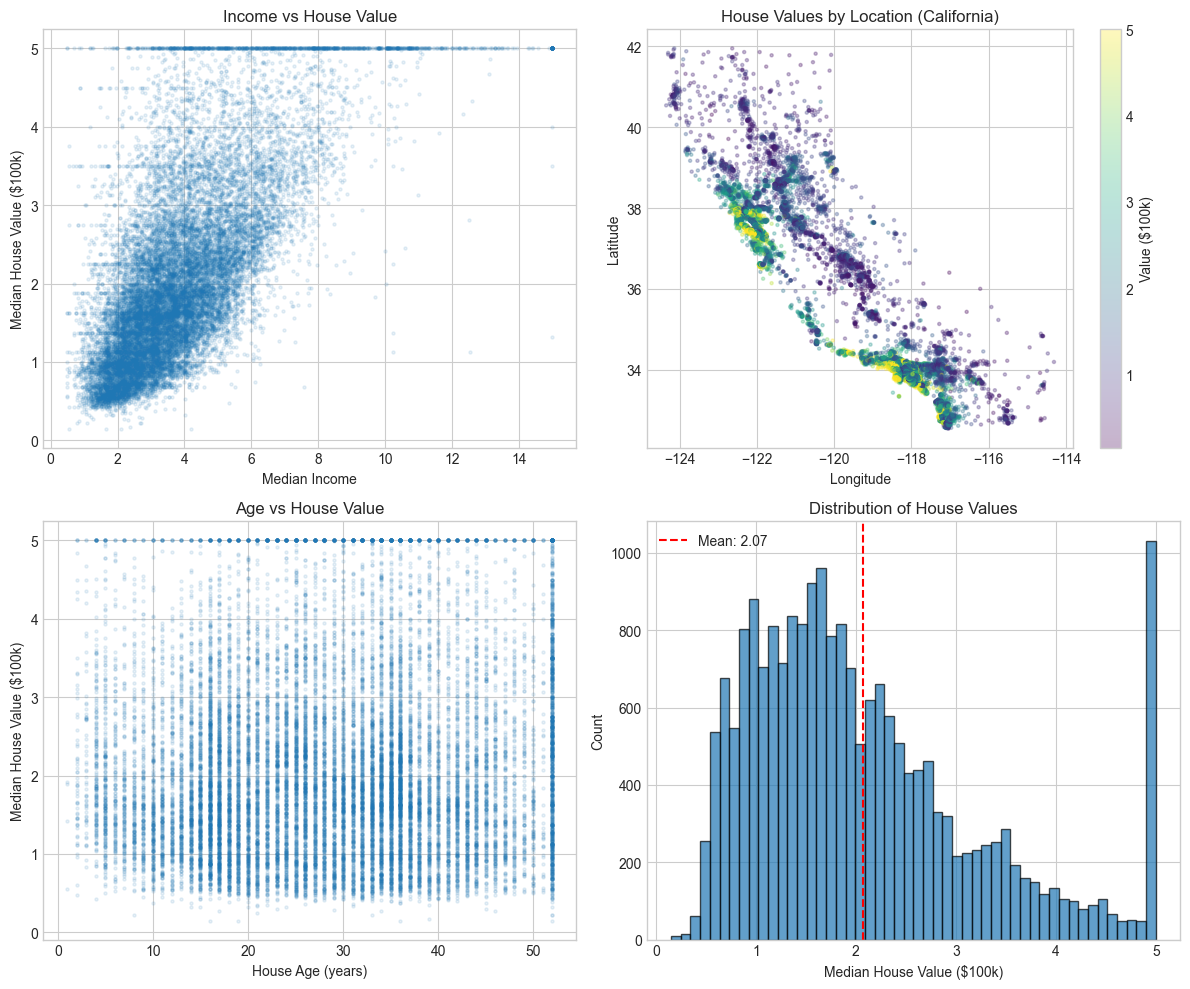


Observations:
• Income is strongly correlated with house value (good feature!)
• Coastal areas (west) have higher values
• House age has weak relationship with value
• Values are capped at $500k (note the spike at 5.0)


In [9]:
# Visualize relationship between features and target
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Median income vs house value
axes[0, 0].scatter(df_housing['MedInc'], df_housing['MedHouseValue'], alpha=0.1, s=5)
axes[0, 0].set_xlabel('Median Income')
axes[0, 0].set_ylabel('Median House Value ($100k)')
axes[0, 0].set_title('Income vs House Value')

# Location (lat/lon)
scatter = axes[0, 1].scatter(df_housing['Longitude'], df_housing['Latitude'], 
                              c=df_housing['MedHouseValue'], cmap='viridis', 
                              alpha=0.3, s=5)
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')
axes[0, 1].set_title('House Values by Location (California)')
plt.colorbar(scatter, ax=axes[0, 1], label='Value ($100k)')

# House age vs value
axes[1, 0].scatter(df_housing['HouseAge'], df_housing['MedHouseValue'], alpha=0.1, s=5)
axes[1, 0].set_xlabel('House Age (years)')
axes[1, 0].set_ylabel('Median House Value ($100k)')
axes[1, 0].set_title('Age vs House Value')

# Target distribution
axes[1, 1].hist(df_housing['MedHouseValue'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Median House Value ($100k)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Distribution of House Values')
axes[1, 1].axvline(df_housing['MedHouseValue'].mean(), color='red', linestyle='--', label=f"Mean: {df_housing['MedHouseValue'].mean():.2f}")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\nObservations:")
print("• Income is strongly correlated with house value (good feature!)")
print("• Coastal areas (west) have higher values")
print("• House age has weak relationship with value")
print("• Values are capped at $500k (note the spike at 5.0)")

### 1.3 Exercise: Identify Features, Labels, and Task Type

For each scenario below, identify:
1. What are the features (X)?
2. What is the label (Y)?
3. Is it classification or regression?
4. How many dimensions would X have?

In [10]:
# Scenario A: Email spam detection
# Features: word counts (e.g., "free": 5, "money": 3, "meeting": 0, ...)
# Label: ???
# Task type: ???

print("Scenario A: Email Spam Detection")
print("="*40)
# YOUR ANSWER HERE
print("Features: Word counts for each word in vocabulary")
print("Label: Spam or Not Spam (binary)")
print("Task: Classification")
print("Dimensions: Number of unique words (could be 10,000+)")
print()

Scenario A: Email Spam Detection
Features: Word counts for each word in vocabulary
Label: Spam or Not Spam (binary)
Task: Classification
Dimensions: Number of unique words (could be 10,000+)



In [11]:
# Scenario B: Predicting tomorrow's temperature
print("Scenario B: Temperature Prediction")
print("="*40)
# YOUR ANSWER HERE
print("Features: Today's temp, humidity, pressure, wind, historical temps...")
print("Label: Tomorrow's temperature (e.g., 23.5°C)")
print("Task: Regression (continuous value)")
print("Dimensions: Depends on features chosen (maybe 10-50)")
print()

Scenario B: Temperature Prediction
Features: Today's temp, humidity, pressure, wind, historical temps...
Label: Tomorrow's temperature (e.g., 23.5°C)
Task: Regression (continuous value)
Dimensions: Depends on features chosen (maybe 10-50)



Scenario C: Digit Recognition
Features: 64 pixel values (8×8 image)
Label: Digit class (0-9)
Task: Classification (10 classes)
Dimensions: 64



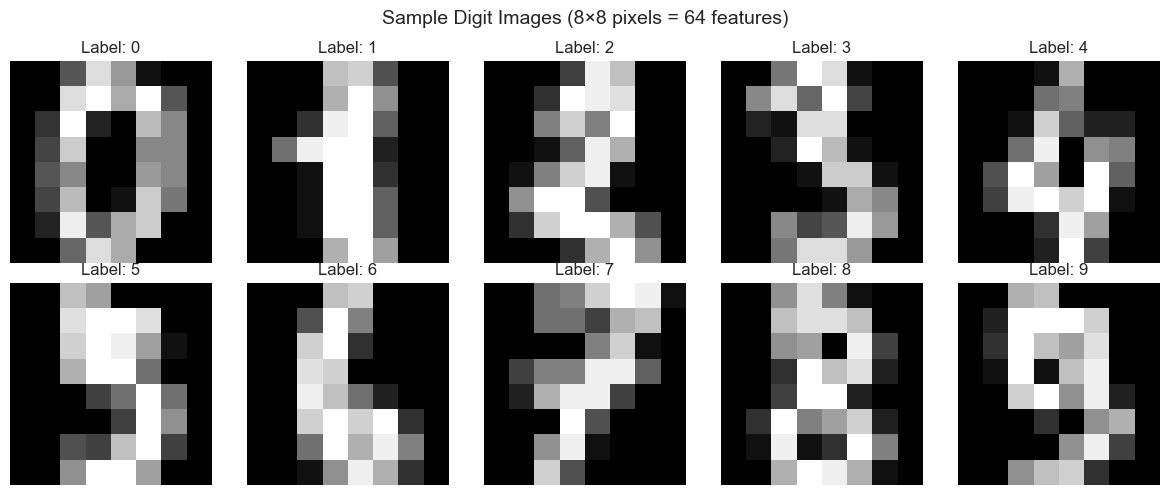

In [12]:
# Scenario C: Handwritten digit recognition
digits = load_digits()

print("Scenario C: Digit Recognition")
print("="*40)
print(f"Features: {digits.data.shape[1]} pixel values (8×8 image)")
print(f"Label: Digit class (0-9)")
print(f"Task: Classification (10 classes)")
print(f"Dimensions: {digits.data.shape[1]}")
print()

# Visualize some digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {digits.target[i]}')
    ax.axis('off')
plt.suptitle('Sample Digit Images (8×8 pixels = 64 features)', fontsize=14)
plt.tight_layout()
plt.show()

---
## Part 2: Numerical vs Categorical Data

Let's explore a dataset with both types of features.

In [13]:
# We'll use the Adult Census dataset (also called Census Income)
# This dataset predicts whether income exceeds $50K/year

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
column_names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 
                'marital-status', 'occupation', 'relationship', 'race', 'sex',
                'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
# Column names are hardcoded because the UCI dataset file has no header row
# The official column names are documented at:
# https://archive.ics.uci.edu/ml/datasets/adult

try:
    adult = pd.read_csv(url, names=column_names, na_values=' ?', skipinitialspace=True)
    print(f"Loaded {len(adult)} samples with {len(adult.columns)} columns")
    print()
    adult.head()
except:
    print("Could not download Adult dataset. Using a simple example instead.")
    adult = None

Loaded 32561 samples with 15 columns



In [15]:
if adult is not None:
    # Identify column types
    print("Data Types:")
    print("="*50)
    
    numerical_cols = adult.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = adult.select_dtypes(include=['object']).columns.tolist()
    
    print(f"\nNumerical features ({len(numerical_cols)}):")
    for col in numerical_cols:
        print(f"  • {col}: range [{adult[col].min()}, {adult[col].max()}]")
    
    print(f"\nCategorical features ({len(categorical_cols)}):")
    for col in categorical_cols:
        n_unique = adult[col].nunique()
        print(f"  • {col}: {n_unique} unique values")

Data Types:

Numerical features (6):
  • age: range [17, 90]
  • fnlwgt: range [12285, 1484705]
  • education-num: range [1, 16]
  • capital-gain: range [0, 99999]
  • capital-loss: range [0, 4356]
  • hours-per-week: range [1, 99]

Categorical features (9):
  • workclass: 9 unique values
  • education: 16 unique values
  • marital-status: 7 unique values
  • occupation: 15 unique values
  • relationship: 6 unique values
  • race: 5 unique values
  • sex: 2 unique values
  • native-country: 42 unique values
  • income: 2 unique values


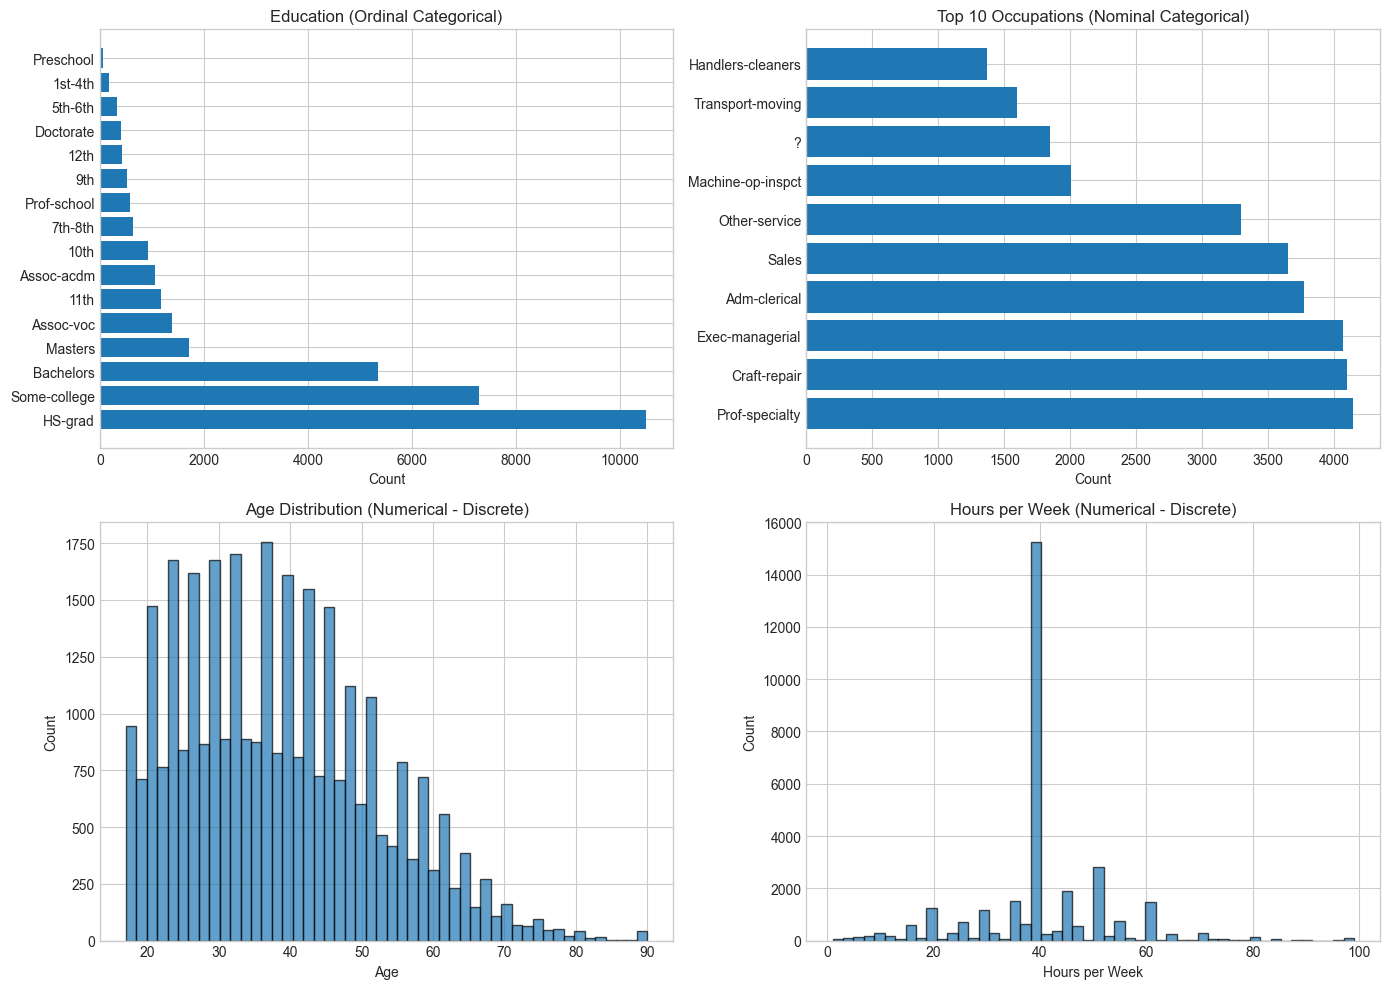


Key Insight:
Categorical features (education, occupation) cannot be used directly in ML.
They must be converted to numbers. We'll learn encoding methods in Lecture 6.


In [18]:
if adult is not None:
    # Look at some categorical features
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Education levels
    edu_counts = adult['education'].value_counts()
    axes[0, 0].barh(edu_counts.index, edu_counts.values)
    axes[0, 0].set_xlabel('Count')
    axes[0, 0].set_title('Education (Ordinal Categorical)')
    
    # Occupation
    occ_counts = adult['occupation'].value_counts().head(10)
    axes[0, 1].barh(occ_counts.index, occ_counts.values)
    axes[0, 1].set_xlabel('Count')
    axes[0, 1].set_title('Top 10 Occupations (Nominal Categorical)')
    
    # Age (numerical)
    axes[1, 0].hist(adult['age'], bins=50, edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('Age')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title('Age Distribution (Numerical - Discrete)')
    
    # Hours per week (numerical)
    axes[1, 1].hist(adult['hours-per-week'], bins=50, edgecolor='black', alpha=0.7)
    axes[1, 1].set_xlabel('Hours per Week')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_title('Hours per Week (Numerical - Discrete)')
    
    plt.tight_layout()
    plt.show()
    
    print("\nKey Insight:")
    print("Categorical features (education, occupation) cannot be used directly in ML.")
    print("They must be converted to numbers. We'll learn encoding methods in Lecture 6.")

Check how the age histogram changes when you change the number of bins. Why do you think this happens?

---
## Part 3: Sampling and Quantization

Let's see how analog signals become digital data.

### 3.1 Sampling: Effect of Sample Rate

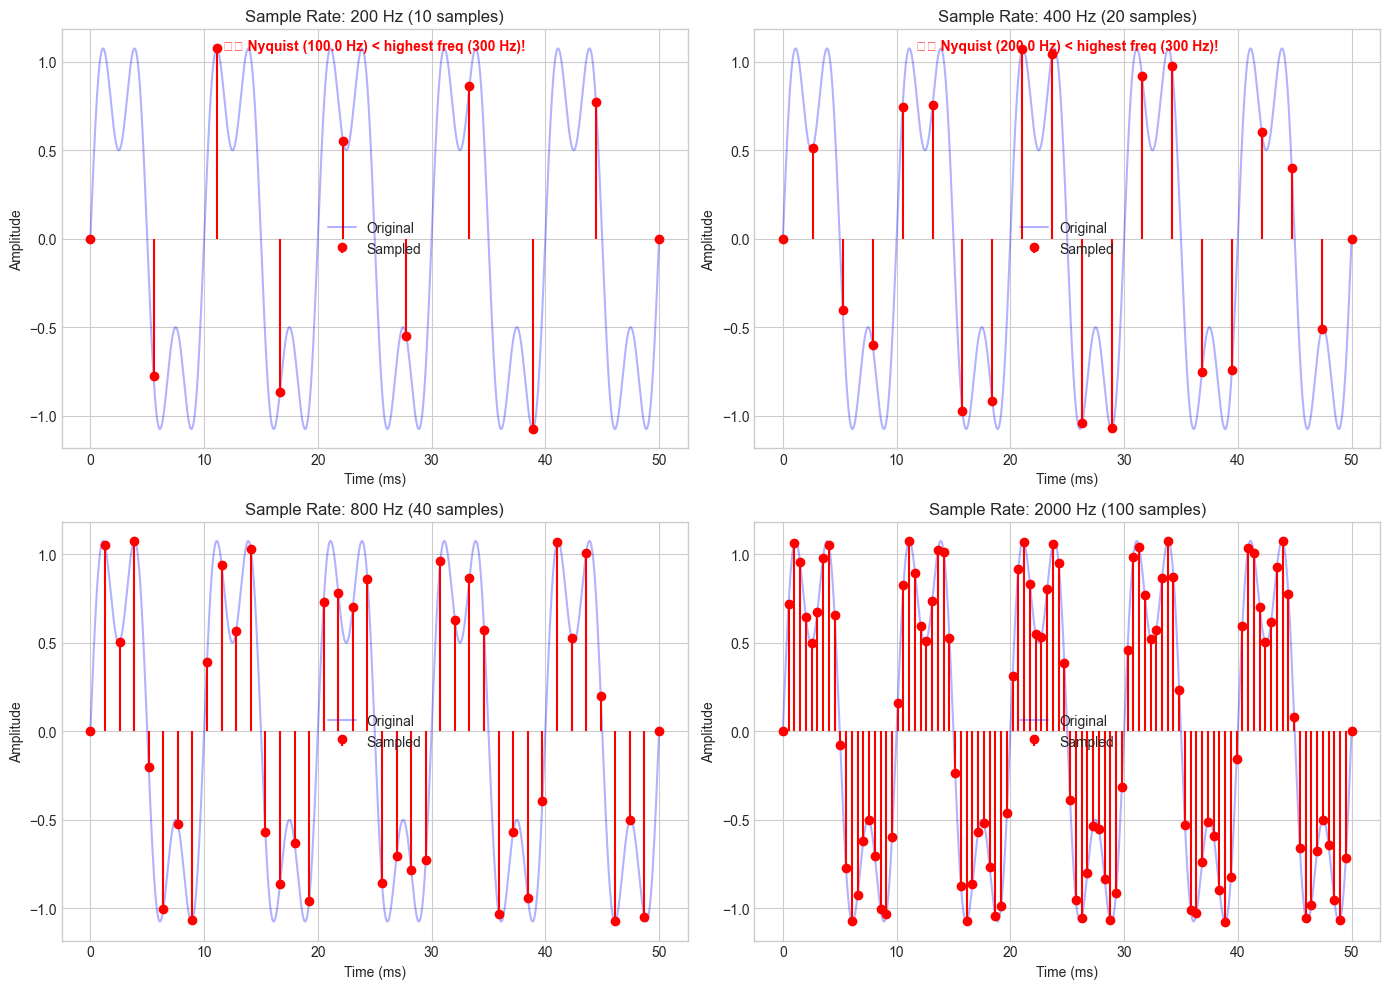


Signal contains frequencies: 100 Hz and 300 Hz
Nyquist theorem: Need at least 600 Hz sample rate

• 200 Hz: Way too slow — can't capture the signal
• 400 Hz: Still too slow — the 300 Hz component is lost
• 800 Hz: Meets Nyquist — captures both frequencies
• 2000 Hz: More than enough — smooth reconstruction possible


In [39]:
# Create a "continuous" signal (actually just very high sample rate)
# This represents an analog signal

# Original signal: combination of two frequencies
duration = 0.05  # 50 milliseconds
freq1 = 100  # 100 Hz
freq2 = 300  # 300 Hz

# "Continuous" signal (very high sample rate to simulate analog)
t_continuous = np.linspace(0, duration, 10000)
signal_continuous = np.sin(2 * np.pi * freq1 * t_continuous) + 0.5 * np.sin(2 * np.pi * freq2 * t_continuous)

# Different sample rates
sample_rates = [200, 400, 800, 2000]  # Hz

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, sr in zip(axes.flat, sample_rates):
    # Sample at this rate
    n_samples = int(duration * sr)
    t_sampled = np.linspace(0, duration, n_samples)
    signal_sampled = np.sin(2 * np.pi * freq1 * t_sampled) + 0.5 * np.sin(2 * np.pi * freq2 * t_sampled)
    
    # Plot
    ax.plot(t_continuous * 1000, signal_continuous, 'b-', alpha=0.3, label='Original')
    ax.stem(t_sampled * 1000, signal_sampled, 'r', markerfmt='ro', basefmt=' ', label='Sampled')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'Sample Rate: {sr} Hz ({n_samples} samples)')
    ax.legend()
    
    # Check Nyquist
    nyquist = sr / 2
    if nyquist < freq2:
        ax.text(0.5, 0.95, f'⚠️ Nyquist ({nyquist} Hz) < highest freq ({freq2} Hz)!', 
                transform=ax.transAxes, ha='center', color='red', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nSignal contains frequencies: {freq1} Hz and {freq2} Hz")
print(f"Nyquist theorem: Need at least {2 * freq2} Hz sample rate")
print("\n• 200 Hz: Way too slow — can't capture the signal")
print("• 400 Hz: Still too slow — the 300 Hz component is lost")
print("• 800 Hz: Meets Nyquist — captures both frequencies")
print("• 2000 Hz: More than enough — smooth reconstruction possible")

### 3.2 Quantization: Effect of Bit Depth

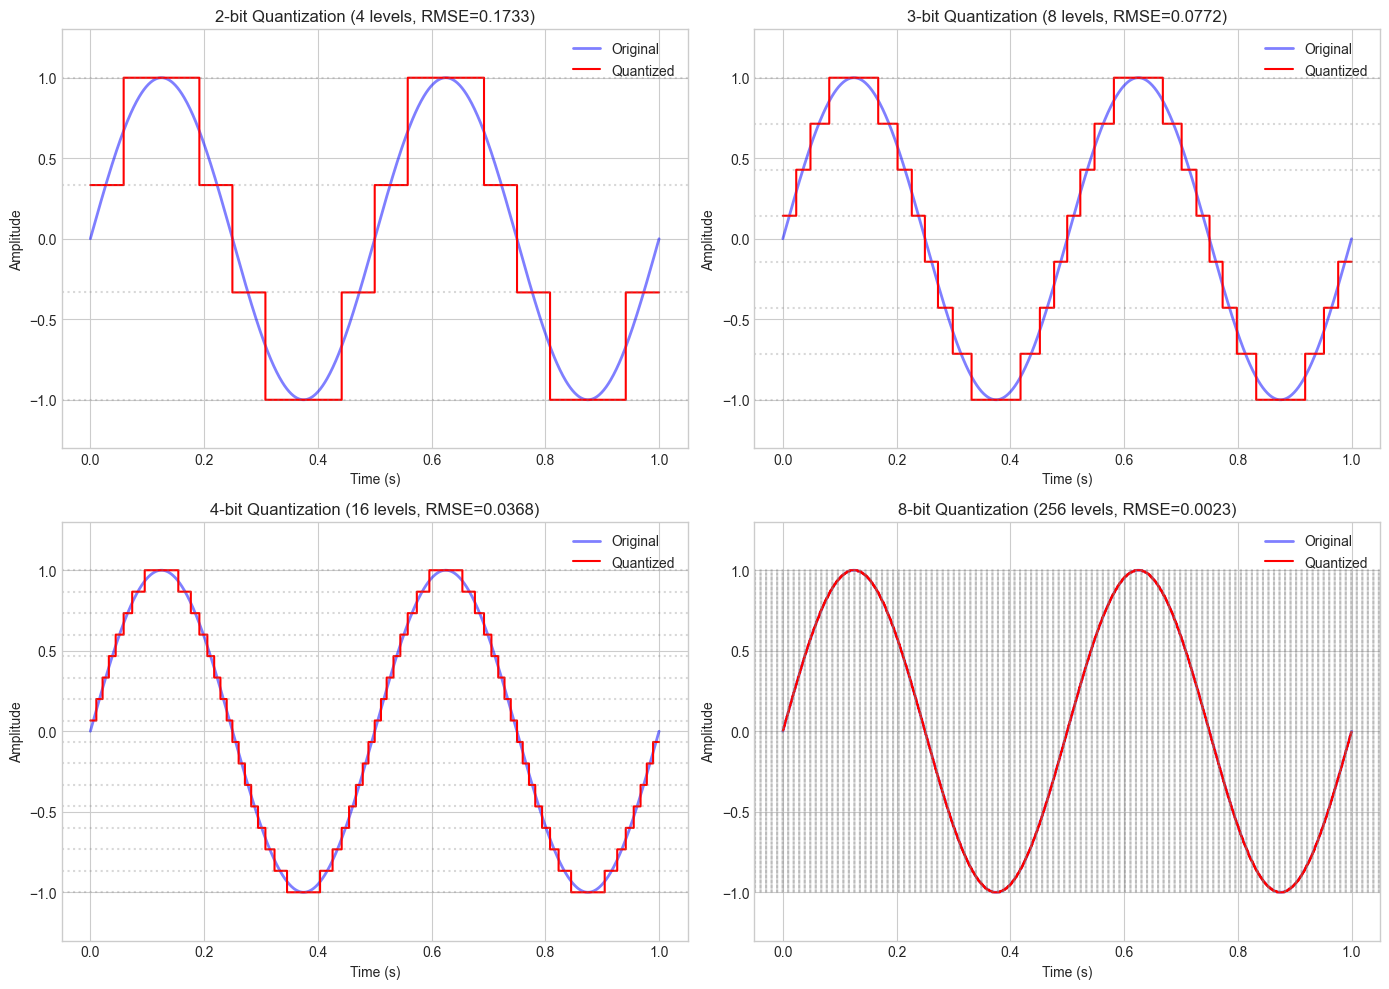


Bit Depth Effects:
• 2-bit: Only 4 levels — very rough approximation (staircase pattern)
• 3-bit: 8 levels — still visible quantization
• 4-bit: 16 levels — better, but still noticeable
• 8-bit: 256 levels — smooth enough for most purposes


In [40]:
# Create a smooth signal
t = np.linspace(0, 1, 1000)
signal = np.sin(2 * np.pi * 2 * t)  # 2 Hz sine wave

# Quantize to different bit depths
bit_depths = [2, 3, 4, 8]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, bits in zip(axes.flat, bit_depths):
    n_levels = 2 ** bits
    
    # Quantize: map [-1, 1] to n_levels discrete values
    # Step 1: Scale to [0, n_levels-1]
    scaled = (signal + 1) / 2 * (n_levels - 1)
    # Step 2: Round to nearest integer
    quantized_int = np.round(scaled).astype(int)
    # Step 3: Scale back to [-1, 1]
    quantized = quantized_int / (n_levels - 1) * 2 - 1
    
    # Calculate quantization error
    error = signal - quantized
    rmse = np.sqrt(np.mean(error**2))
    
    # Plot
    ax.plot(t, signal, 'b-', alpha=0.5, label='Original', linewidth=2)
    ax.step(t, quantized, 'r-', where='mid', label='Quantized', linewidth=1.5)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'{bits}-bit Quantization ({n_levels} levels, RMSE={rmse:.4f})')
    ax.legend()
    ax.set_ylim(-1.3, 1.3)
    
    # Show quantization levels
    levels = np.linspace(-1, 1, n_levels)
    for level in levels:
        ax.axhline(y=level, color='gray', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nBit Depth Effects:")
print("• 2-bit: Only 4 levels — very rough approximation (staircase pattern)")
print("• 3-bit: 8 levels — still visible quantization")
print("• 4-bit: 16 levels — better, but still noticeable")
print("• 8-bit: 256 levels — smooth enough for most purposes")

### 3.3 Real Audio: Sample Rate Comparison

Let's load a real audio file and see the effect of different sample rates.

Original: 22050 Hz, 117601 samples, 5.33 seconds

🔊 Audio Playback (listen to the difference!):

4000 Hz:


8000 Hz:


16000 Hz:


22050 Hz:


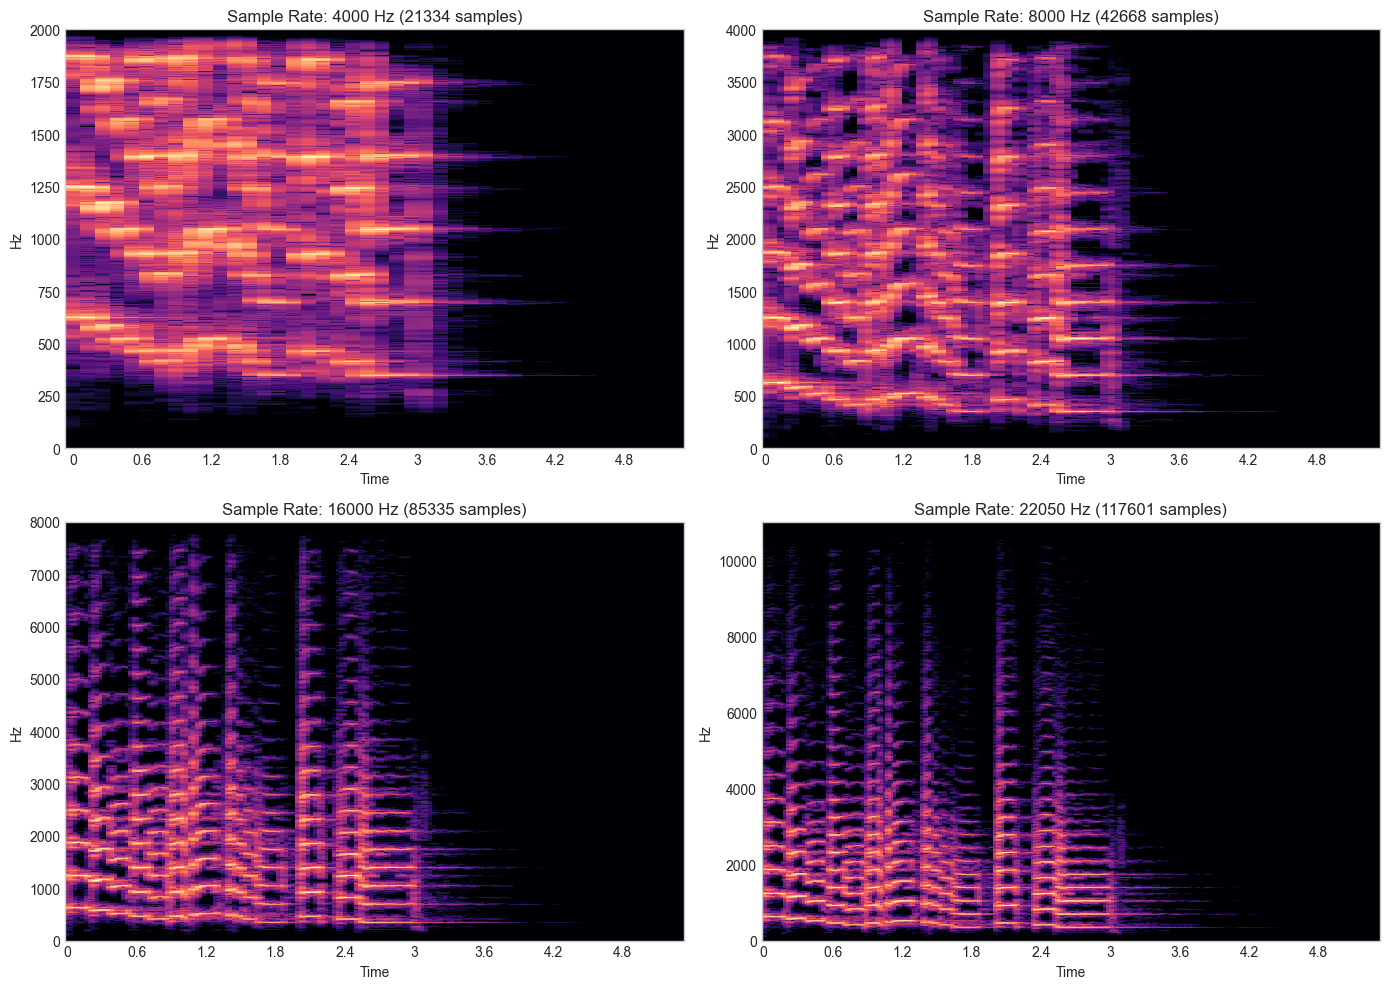


Observations:
• Lower sample rates cut off higher frequencies (Nyquist limit)
• 4 kHz: Only frequencies up to 2 kHz (phone quality - sounds muffled)
• 16 kHz: Up to 8 kHz (good for speech - clearer)
• 22050 Hz: Full frequency range (brightest, most detail)

💡 Listen carefully: Can you hear the high frequencies disappearing at lower sample rates?


In [5]:
if LIBROSA_AVAILABLE:
    from IPython.display import Audio, display
    
    # Load a sample audio file (comes with librosa)
    audio_path = librosa.example('trumpet')
    
    # Load at original sample rate
    y_original, sr_original = librosa.load(audio_path, sr=None)
    print(f"Original: {sr_original} Hz, {len(y_original)} samples, {len(y_original)/sr_original:.2f} seconds")
    
    # Resample to different rates
    sample_rates = [4000, 8000, 16000, sr_original]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    print("\n🔊 Audio Playback (listen to the difference!):\n")
    
    for ax, sr in zip(axes.flat, sample_rates):
        # Resample
        y_resampled = librosa.resample(y_original, orig_sr=sr_original, target_sr=sr)
        
        # Compute spectrogram
        D = librosa.amplitude_to_db(np.abs(librosa.stft(y_resampled)), ref=np.max)
        
        # Plot
        librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=ax)
        ax.set_title(f'Sample Rate: {sr} Hz ({len(y_resampled)} samples)')
        ax.set_ylim(0, sr/2)  # Up to Nyquist frequency
        
        # Add audio player
        print(f"{sr} Hz:")
        display(Audio(y_resampled, rate=sr))
    
    plt.tight_layout()
    plt.show()
    
    print("\nObservations:")
    print("• Lower sample rates cut off higher frequencies (Nyquist limit)")
    print("• 4 kHz: Only frequencies up to 2 kHz (phone quality - sounds muffled)")
    print("• 16 kHz: Up to 8 kHz (good for speech - clearer)")
    print(f"• {sr_original} Hz: Full frequency range (brightest, most detail)")
    print("\n💡 Listen carefully: Can you hear the high frequencies disappearing at lower sample rates?")
else:
    print("Skipping audio example (librosa not available)")

### 3.4 Image Resolution as Spatial Sampling

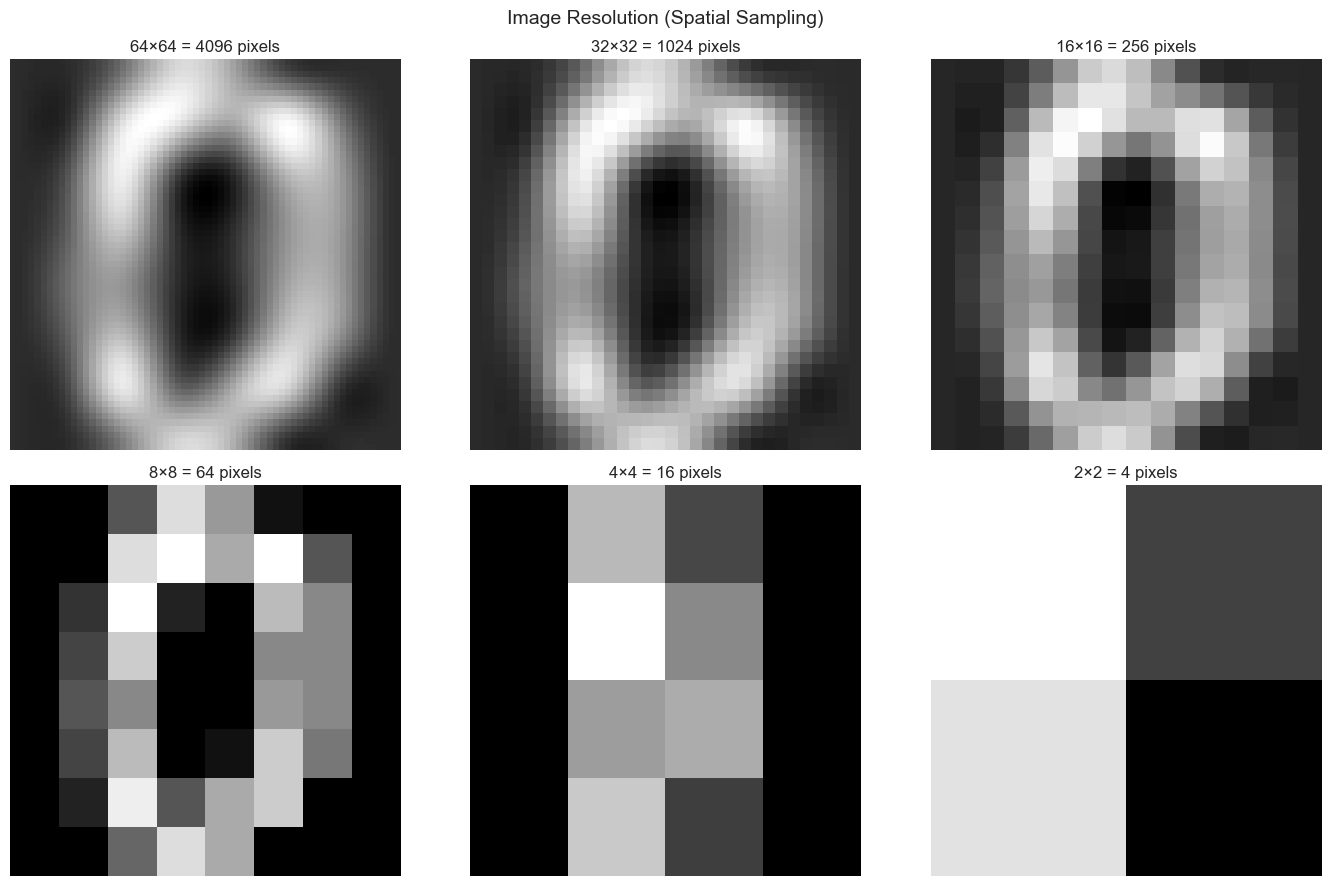


Image Resolution Trade-offs:
• 64×64 (4096 features): Clear, lots of detail
• 32×32 (1024 features): Still recognizable
• 16×16 (256 features): Getting blocky
• 8×8 (64 features): The original MNIST-like resolution
• 4×4 (16 features): Barely recognizable
• 2×2 (4 features): Impossible to recognize

For digit classification, 8×8 is often sufficient!


In [42]:
# Use a digit from the digits dataset as our "high resolution" image
# Then downsample it

from scipy.ndimage import zoom

# Get a digit (8x8)
original = digits.images[0]

# "Upsample" to simulate higher resolution, then downsample back
high_res = zoom(original, 8, order=3)  # 64x64

# Different resolutions
resolutions = [64, 32, 16, 8, 4, 2]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for ax, res in zip(axes.flat, resolutions):
    # Downsample
    scale = res / 64
    downsampled = zoom(high_res, scale, order=1)
    
    # Plot (upscale for display without interpolation)
    ax.imshow(downsampled, cmap='gray', interpolation='nearest')
    ax.set_title(f'{res}×{res} = {res*res} pixels')
    ax.axis('off')

plt.suptitle('Image Resolution (Spatial Sampling)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nImage Resolution Trade-offs:")
print("• 64×64 (4096 features): Clear, lots of detail")
print("• 32×32 (1024 features): Still recognizable")
print("• 16×16 (256 features): Getting blocky")
print("• 8×8 (64 features): The original MNIST-like resolution")
print("• 4×4 (16 features): Barely recognizable")
print("• 2×2 (4 features): Impossible to recognize")
print("\nFor digit classification, 8×8 is often sufficient!")

---
## Summary

In this lab, we explored:

1. **Features and Labels**: Features (X) are inputs, labels (Y) are outputs. The number of features = number of dimensions.

2. **Classification vs Regression**: Classification predicts categories, regression predicts continuous values.

3. **Numerical vs Categorical**: Numerical features can be used directly; categorical features need encoding.

4. **Sampling**: Converting continuous time to discrete samples. Sample rate determines frequency resolution (Nyquist theorem).

5. **Quantization**: Converting continuous values to discrete levels. Bit depth determines precision.


### Next Steps
In Lab 1b, we'll learn:
- How to handle missing values
- How to normalize and standardize features
- How to reduce dimensions with PCA

In [8]:
# Final summary table
print("\n" + "="*60)
print("SUMMARY: Key Concepts from Lab 1a")
print("="*60)

summary = pd.DataFrame({
    'Concept': ['Features (X)', 'Labels (Y)', 'Dimensions', 'Classification', 
                'Regression', 'Sample Rate', 'Bit Depth'],
    'Definition': [
        'Input measurements for each sample',
        'Output to predict (target)',
        'Number of features',
        'Predict categories',
        'Predict continuous values',
        'Samples per second (Hz)',
        'Bits per sample (precision)'
    ],
    'Example': [
        'Pixel values, word counts, measurements',
        'Species, price, spam/not-spam',
        '784 pixels = 784D',
        'Spam detection, image recognition',
        'Price prediction, temperature forecast',
        '44.1 kHz for CD audio',
        '16-bit for CD quality'
    ]
})

print(summary.to_string(index=False))


SUMMARY: Key Concepts from Lab 1a
       Concept                         Definition                                 Example
  Features (X) Input measurements for each sample Pixel values, word counts, measurements
    Labels (Y)         Output to predict (target)           Species, price, spam/not-spam
    Dimensions                 Number of features                       784 pixels = 784D
Classification                 Predict categories       Spam detection, image recognition
    Regression          Predict continuous values  Price prediction, temperature forecast
   Sample Rate            Samples per second (Hz)                   44.1 kHz for CD audio
     Bit Depth        Bits per sample (precision)                   16-bit for CD quality
